<a href="https://colab.research.google.com/github/deepakk7195/IISC_CDS_DS/blob/Big-Data/MiniProject_2_Simple_Analytics_Pyspark_Priyanka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini-Project: Simple Analytics using Pyspark

## Problem Statement

Perform simple analytics with Pyspark on the real estate valuation dataset and predict the house price per unit area

## Learning Objectives

At the end of the mini-project, you will be able to :

* analyze the data using pyspark
* derive the insights and visualize the data
* implement linear regression and evaluate using pyspark

### Dataset

The dataset chosen for this mini-project is **Real Estate Valuation dataset**. The data was collected from the historical market of real estate within Sindian District of New Taipei City, the timespan across 2012 August to 2013 July. In the dataset, the response variable (house price per unit area) is calculated in a local unit which is approximately $10000 New Taipei Dollar per 3.3 squared meters. For the collection of regressor data, the transaction dates are transformed into a format such that 2013.250 = 2013 March, 2013.500 = 2013 June etc. The house age was collected in years and the distance to MRT stations is measured in meters.

**Reference:**
The original owner of this Real Estate Valuation dataset is professor I-Cheng Yeh from TamKang University (Department of Civil Engineering). Prof. Yeh donated this dataset to UCI machine learning repository on 18th August 2018. The dataset can be accessed at https://archive.ics.uci.edu/ml/datasets/Real+estate+valuation+data+set#[1].

## Grading = 10 Points

#### Install Pyspark

In [ ]:
#@title Install pyspark and Download the data
!pip -qq install pyspark
!pip -qq install handyspark
!pip install numpy==1.23.0
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/RealEstate.csv
print("Packages installed and dataset downloaded successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.0/17.0 MB 78.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albucore 0.0.16 requires numpy>=1.24, but you have numpy 1.23.0 which is incompatible.
albumentations 1.4.15 requires numpy>=1.24.4, but you have numpy 1.23.0 which is incompatible.
bigframes 1.18.0 requires numpy>=1.24.0, but you have numpy 1.23.0 which is incompatible.
chex 0.1.86 requires numpy>=1.24.1, but you have numpy 1.23.0 which is incompatible.
ibis-framework 9.2.0 requires numpy<3,>=1.23.2, but you have numpy 1.23.0 which is incompatible.
jax 0.4.33 require

Packages installed and dataset downloaded successfully!


#### Import required packages

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.feature import MinMaxScaler
from handyspark import *
import seaborn as sns
from matplotlib import pyplot as plt

### Data Loading (1 point)

#### Start a Spark Session

Spark session is a combined entry point of a Spark application, which came into implementation from Spark 2.0. It provides a way to interact with various spark’s functionality with a lesser number of constructs.

In [ ]:
spark = SparkSession.builder.appName('RealEstate').getOrCreate()
spark

#### Load the data and infer the schema

To load the dataset use the `read.csv` with `inferSchema` and `header` as parameters.

In [ ]:
csv_path = "/content/RealEstate.csv"
dfrealestate = spark.read.csv(csv_path, sep = ",", header=True, inferSchema = True)  # creating spark data frame

In [ ]:
# Print the data types
dfrealestate.dtypes

[('No', 'int'),
 ('X1 transaction date', 'double'),
 ('X2 house age', 'double'),
 ('X3 distance to the nearest MRT station', 'double'),
 ('X4 number of convenience stores', 'int'),
 ('X5 latitude', 'double'),
 ('X6 longitude', 'double'),
 ('Y house price of unit area', 'double')]

In [ ]:
# Print the Schema of the DataFrame
dfrealestate.printSchema()

root
 |-- No: integer (nullable = true)
 |-- X1 transaction date: double (nullable = true)
 |-- X2 house age: double (nullable = true)
 |-- X3 distance to the nearest MRT station: double (nullable = true)
 |-- X4 number of convenience stores: integer (nullable = true)
 |-- X5 latitude: double (nullable = true)
 |-- X6 longitude: double (nullable = true)
 |-- Y house price of unit area: double (nullable = true)



In [ ]:
#Display rows
dfrealestate.show(5)

+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+
| No|X1 transaction date|X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|X5 latitude|X6 longitude|Y house price of unit area|
+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+
|  1|           2012.917|        32.0|                              84.87882|                             10|   24.98298|   121.54024|                      37.9|
|  2|           2012.917|        19.5|                              306.5947|                              9|   24.98034|   121.53951|                      42.2|
|  3|           2013.583|        13.3|                              561.9845|                              5|   24.98746|   121.54391|                      47.3|
|  4|             2013.5|   

In [ ]:
#Total No of Rows
dfrealestate.count()

414

In [ ]:
#Describe dataframe
dfrealestate.describe().show()

+-------+-----------------+-------------------+------------------+--------------------------------------+-------------------------------+--------------------+--------------------+--------------------------+
|summary|               No|X1 transaction date|      X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|         X5 latitude|        X6 longitude|Y house price of unit area|
+-------+-----------------+-------------------+------------------+--------------------------------------+-------------------------------+--------------------+--------------------+--------------------------+
|  count|              414|                414|               414|                                   414|                            414|                 414|                 414|                       414|
|   mean|            207.5| 2013.1489710144933| 17.71256038647343|                    1083.8856889130436|              4.094202898550725|  24.969030072463745|  121.53336108

#### Fetch the data using handyspark

* Create a HandyFrame using handyspark `toHandy()` function

* using an instance of `cols` from your HandyFrame, you can retrieve values for given columns in the top N rows

Hint: [toHandy()](https://dvgodoy.github.io/handyspark/includeme.html)

In [ ]:
from handyspark import *
sdfrealestate = spark.read.csv('/content/RealEstate.csv', header=True, inferSchema=True)
hdfrealestate = sdfrealestate.toHandy()

/usr/local/lib/python3.10/dist-packages/pyspark/sql/dataframe.py:168: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pyspark/sql/dataframe.py:147: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


In [ ]:
# Define the columns we want to display
columns_of_interest =['X2 house age','X3 distance to the nearest MRT station','Y house price of unit area']

In [ ]:
# Retrieve the top 10 rows for the specified columns
hdfrealestate.cols[columns_of_interest][:20]

/usr/local/lib/python3.10/dist-packages/pyspark/sql/dataframe.py:168: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pyspark/sql/dataframe.py:147: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


,X2 house age,X3 distance to the nearest MRT station,Y house price of unit area
0,32.0,84.87882,37.9
1,19.5,306.59470,42.2
2,13.3,561.98450,47.3
3,13.3,561.98450,54.8
4,5.0,390.56840,43.1
5,7.1,2175.03000,32.1
6,34.5,623.47310,40.3
7,20.3,287.60250,46.7
8,31.7,5512.03800,18.8
9,17.9,1783.18000,22.1


### Deriving the insights (2 points)

#### show the no. of records per month

Hint: Apply [groupby](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.GroupedData.agg.html) on transaction date and count the records using aggregation `agg()`

In [ ]:
#Count distinct dates
dfrealestate.select('X1 transaction date').distinct().count()

12

In [ ]:
#distinct transaction dates
dfrealestate.select('X1 transaction date').distinct().show()

+-------------------+
|X1 transaction date|
+-------------------+
|            2012.75|
|           2013.333|
|           2013.083|
|             2013.5|
|           2013.417|
|           2013.167|
|           2012.833|
|           2013.583|
|            2013.25|
|             2013.0|
|           2012.917|
|           2012.667|
+-------------------+



In [ ]:
# the no. of records per month
dfrealestate.groupBy('X1 transaction date').agg({"*": "count"}).show()

+-------------------+--------+
|X1 transaction date|count(1)|
+-------------------+--------+
|            2012.75|      27|
|           2013.333|      29|
|           2013.083|      46|
|           2012.833|      31|
|             2013.5|      47|
|           2013.583|      23|
|           2013.417|      58|
|           2013.167|      25|
|            2013.25|      32|
|             2013.0|      28|
|           2012.917|      38|
|           2012.667|      30|
+-------------------+--------+



In [ ]:
# Aggregate to count transactions by date
transaction_counts = dfrealestate.groupBy('X1 transaction date').agg(count('*').alias('transaction_count')).orderBy('X1 transaction date')
#Convert to Pandas DataFrame for plotting
pandas_dftrxncnt = transaction_counts.toPandas()
pandas_dftrxncnt.head(12)

,X1 transaction date,transaction_count
0,2012.667,30
1,2012.750,27
2,2012.833,31
3,2012.917,38
4,2013.000,28
5,2013.083,46
6,2013.167,25
7,2013.250,32
8,2013.333,29
9,2013.417,58


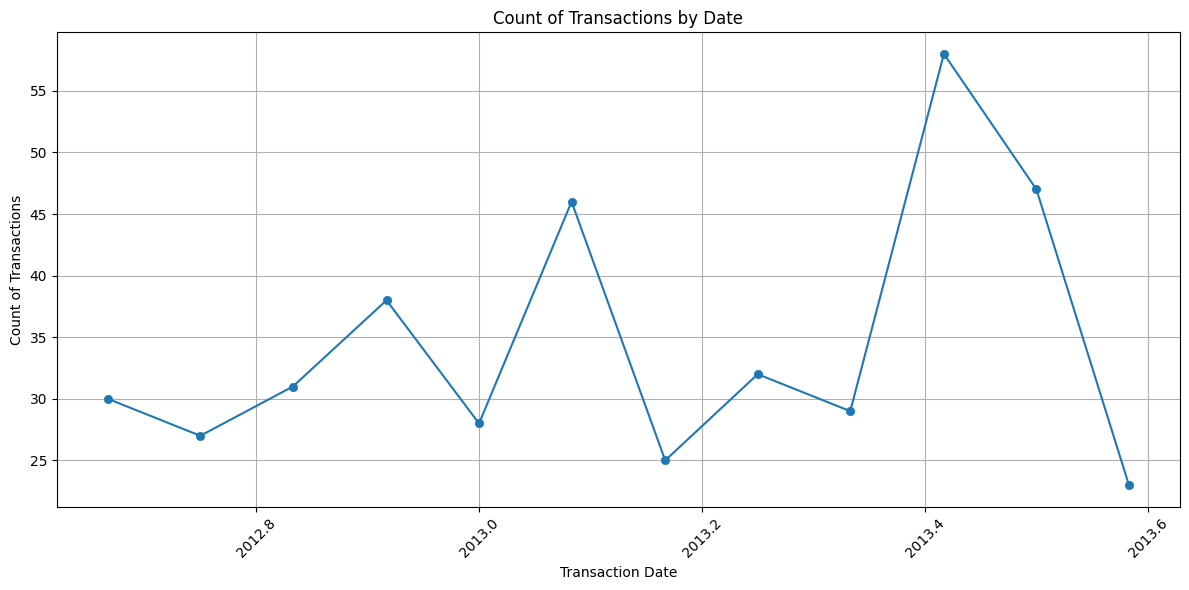

In [ ]:

plt.figure(figsize=(12, 6))
plt.plot(pandas_dftrxncnt['X1 transaction date'], pandas_dftrxncnt['transaction_count'],marker ='o')
plt.title('Count of Transactions by Date')
plt.xlabel('Transaction Date')
plt.ylabel('Count of Transactions')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

#### how much is the increase in the average house price in 2012 to 2013

Hint: Apply [filter](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.sql.DataFrame.filter.html) on the transaction date and aggregate the house price using mean

In [ ]:
from pyspark.sql.functions import col, min
# #Calculate the average house price for 2012
# average_prices_2012 = dfrealestate.filter(((dfrealestate['X1 transaction date']).cast('int')).isin(2012)).agg(mean('Y house price of unit area').alias('average_price_2012'))
# #Calculate the average house price for 2013
# average_prices_2013 = dfrealestate.filter(((dfrealestate['X1 transaction date']).cast('int')).isin(2013)).agg(mean('Y house price of unit area').alias('average_price_2013'))
# average_prices_2012.show()
# average_prices_2013.show()

# # Extract the average price values from the DataFrames
# avg_price_2012 = average_prices_2012.collect()[0]['average_price_2012']
# avg_price_2013 = average_prices_2013.collect()[0]['average_price_2013']

# increase = avg_price_2013 - avg_price_2012

# print(f"Increase in average house price from 2012 to 2013: {increase:.2f}")


+------------------+
|average_price_2012|
+------------------+
|36.304761904761904|
+------------------+

+------------------+
|average_price_2013|
+------------------+
|38.713194444444454|
+------------------+

Increase in average house price from 2012 to 2013: 2.41


In [ ]:
dfrealestate = dfrealestate.withColumn("Year", floor(dfrealestate['X1 transaction date']))

dfrealestate_2012 = dfrealestate.filter(dfrealestate["Year"] == 2012)
dfrealestate_2013 = dfrealestate.filter(dfrealestate["Year"] == 2013)

avg_price_2012 = dfrealestate_2012.agg(avg("Y house price of unit area")).collect()[0][0]
avg_price_2013 = dfrealestate_2013.agg(avg("Y house price of unit area")).collect()[0][0]

# Calculate the percentage increase
price_increase = ((avg_price_2013 - avg_price_2012) / avg_price_2012) * 100
print(price_increase)

6.633930132913636


#### Find the count of houses with no convenience store and show the top 10 records

In [ ]:
#count of houses with no convenience store
dfrealestate.filter(col('X4 number of convenience stores')== 0).count()

67

In [ ]:
dfrealestate.filter(col('X4 number of convenience stores')== 0).orderBy(col('Y house price of unit area').desc()).show(10)

+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+----+
| No|X1 transaction date|X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|X5 latitude|X6 longitude|Y house price of unit area|Year|
+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+----+
|387|           2012.833|         0.0|                              185.4296|                              0|    24.9711|    121.5317|                      55.3|2012|
|165|           2012.833|         0.0|                              185.4296|                              0|    24.9711|    121.5317|                      55.2|2012|
|147|            2012.75|         0.0|                              185.4296|                              0|    24.9711|    121.5317|                      52.2|2012

#### Compare the maximum price of houses *with convenient store* and *without convenience store*

In [ ]:
#Maximum price of house without store
dfrealestate.filter(col('X4 number of convenience stores')== 0).agg(max('Y house price of unit area').alias('max_price_without_convenience')).show()

+-----------------------------+
|max_price_without_convenience|
+-----------------------------+
|                         55.3|
+-----------------------------+



In [ ]:
#Maximum price of house with store
dfrealestate.filter(col('X4 number of convenience stores')> 0).agg(max('Y house price of unit area').alias('max_price_with_convenience')).show()

+--------------------------+
|max_price_with_convenience|
+--------------------------+
|                     117.5|
+--------------------------+



#### Decode the transaction date

* create a year column separately by removing the decimal places from transaction date column

    Hint: `withColumn()`

* create a month column separately based on the decimal places from the transaction date column

 **Hints:** multiply decimal place number with 12 and apply round off, perform below steps
     
     - use `udf()` from pyspark
     - subtracting `transaction date` from `int(transaction date)` will give the decimal place number
     - multiply the result with 12 and roundoff

To know more about udf(), click [here](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.functions.udf.html)

In [ ]:
##Check and remove the additional year column
# Create a year column
dfrealestate_yr = dfrealestate.withColumn('year1', dfrealestate['X1 transaction date'].cast('int'))
# Show the result
dfrealestate_yr.show()

+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+----+-----+
| No|X1 transaction date|X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|X5 latitude|X6 longitude|Y house price of unit area|Year|year1|
+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+----+-----+
|  1|           2012.917|        32.0|                              84.87882|                             10|   24.98298|   121.54024|                      37.9|2012| 2012|
|  2|           2012.917|        19.5|                              306.5947|                              9|   24.98034|   121.53951|                      42.2|2012| 2012|
|  3|           2013.583|        13.3|                              561.9845|                              5|   24.98746|   121.54391| 

In [ ]:
transaction_date ='2013.417'
print(int(float(transaction_date)))
print(float(transaction_date) - int(float(transaction_date)))
print((float(transaction_date) - int(float(transaction_date))) * 12)
print(int((float(transaction_date) - int(float(transaction_date))) * 12))

2013
0.4169999999999163
5.003999999998996
5


In [ ]:
from pyspark.sql.types import IntegerType
#Define UDF using lambda to calculate the month from the decimal part
extract_month_udf = udf(lambda transaction_date: int((float(transaction_date) - int(float(transaction_date))) * 12))
# Create a month column using the UDF
dfrealestate_yr_mon = dfrealestate_yr.withColumn('month', extract_month_udf(dfrealestate_yr['X1 transaction date']))
dfrealestate_yr_mon.show()

+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+----+-----+
| No|X1 transaction date|X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|X5 latitude|X6 longitude|Y house price of unit area|year|month|
+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+----+-----+
|  1|           2012.917|        32.0|                              84.87882|                             10|   24.98298|   121.54024|                      37.9|2012|   11|
|  2|           2012.917|        19.5|                              306.5947|                              9|   24.98034|   121.53951|                      42.2|2012|   11|
|  3|           2013.583|        13.3|                              561.9845|                              5|   24.98746|   121.54391| 

### Data Visualization (2 points)

#### Select the continuous variables from the data and visualize using histogram

In [ ]:
dfrealestate_yr_mon.dtypes

[('No', 'int'),
 ('X1 transaction date', 'double'),
 ('X2 house age', 'double'),
 ('X3 distance to the nearest MRT station', 'double'),
 ('X4 number of convenience stores', 'int'),
 ('X5 latitude', 'double'),
 ('X6 longitude', 'double'),
 ('Y house price of unit area', 'double'),
 ('year', 'int'),
 ('month', 'string')]

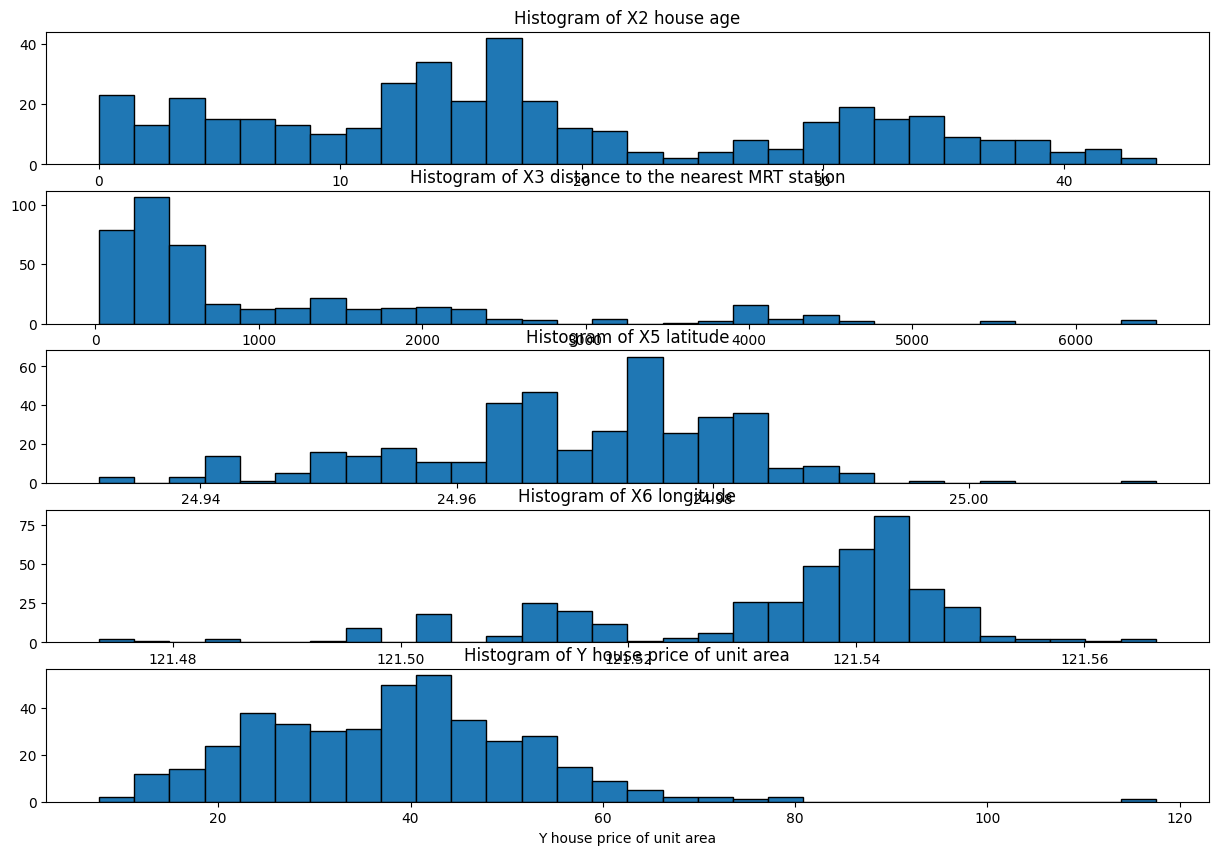

In [ ]:
#Continuous Variables
continuous_variables = ['X2 house age', 'X3 distance to the nearest MRT station','X5 latitude','X6 longitude' ,'Y house price of unit area']

#Convert to Pandas DataFrame for visualization
pandas_dfhist = dfrealestate_yr_mon.select(continuous_variables).toPandas()
#pandas_df.head()


# Step 4: Visualize using histograms
plt.figure(figsize=(15, 10))
for i, column in enumerate(continuous_variables, 1):
    plt.subplot(len(continuous_variables), 1, i)
    plt.hist(pandas_dfhist[column], bins=30, edgecolor='black')
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)



#### Visualize the transaction date using the countplot

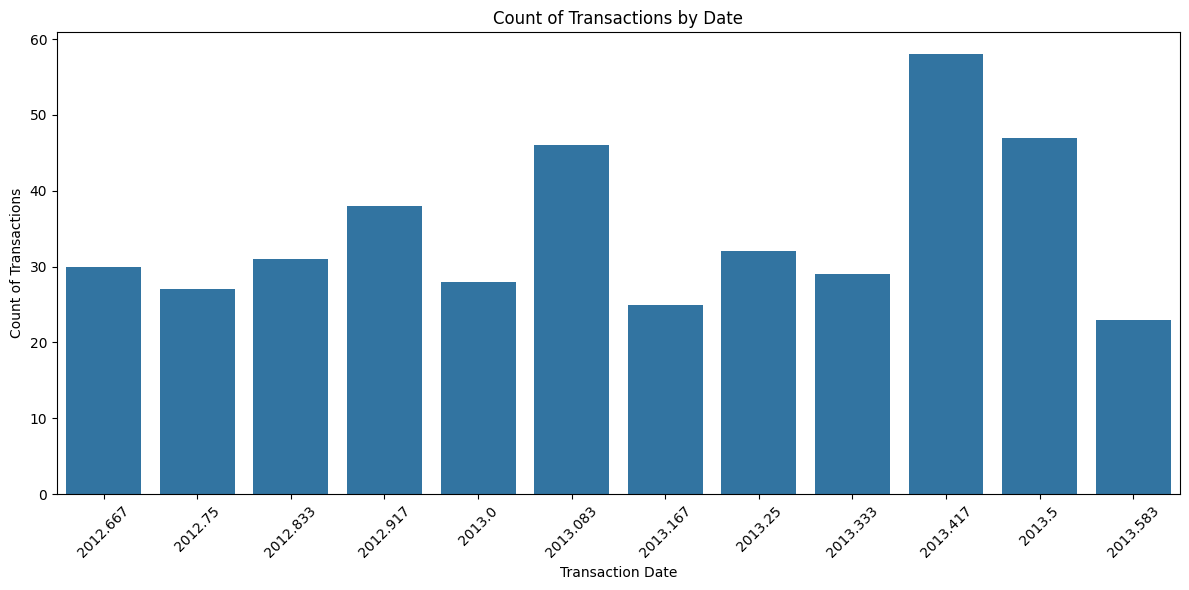

In [ ]:
# Create a count plot for the transactions
dftrcnt = dfrealestate_yr_mon.select('X1 transaction date').toPandas()
plt.figure(figsize=(12, 6))
sns.countplot(data=dftrcnt, x='X1 transaction date')
plt.title('Count of Transactions by Date')
plt.xlabel('Transaction Date')
plt.ylabel('Count of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### visualize number of convenience stores with appropriate plot.

In [ ]:
#To-Do

#### visualize the geographical distribution of the house prices of unit area

With:

* x-axis = X6 longitude
* y-axis = X5 latitude
* datapoints = Y house price of unit area
* parameters including size `s` and color map `cmap`

In [ ]:
# To-Do

### Feature Scaling (1 point)

#### Identify the outliers

Use the pairplot or boxplot to identify the outliers

   **Hint:** `sns.pairplot`

#To be edited

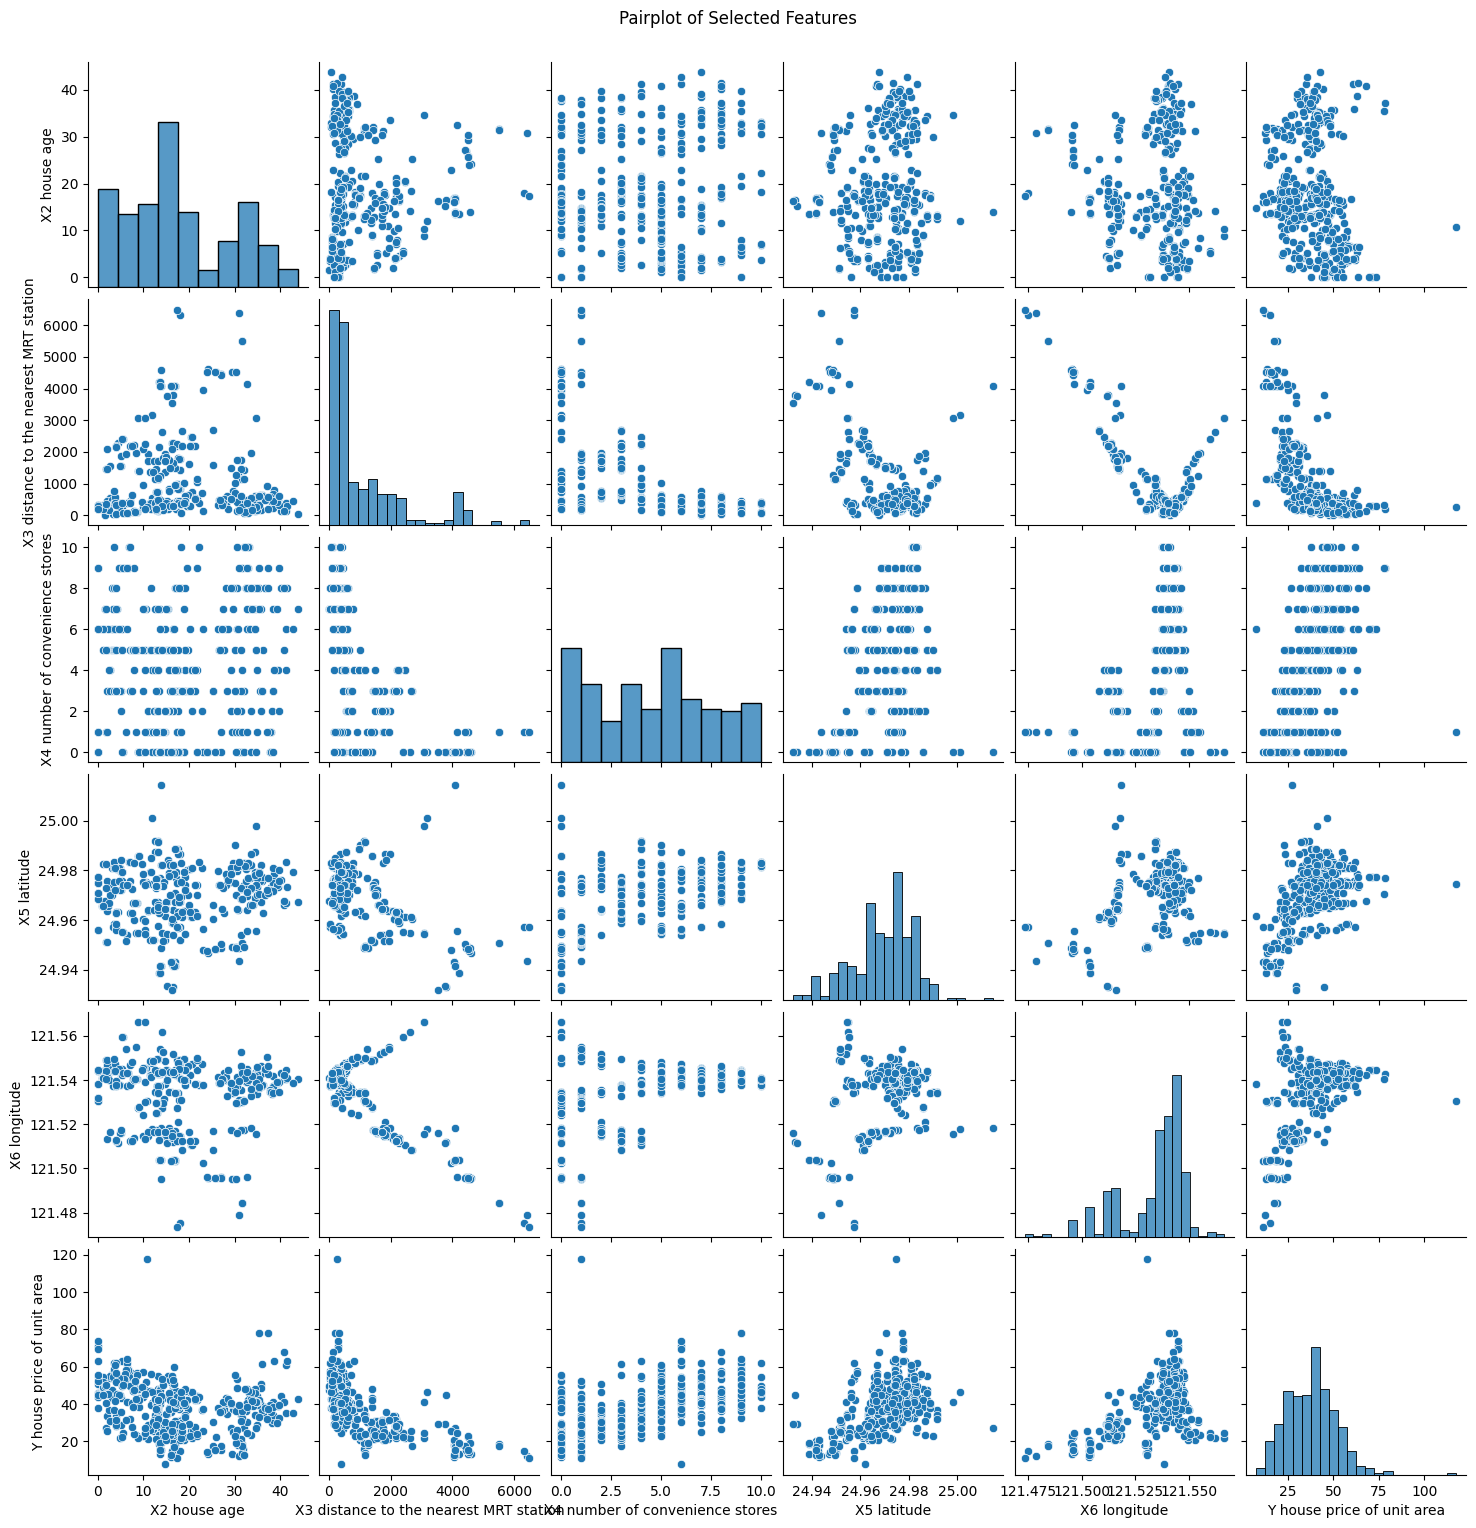

In [ ]:
# Features Selected
selected_columns = ['X2 house age', 'X3 distance to the nearest MRT station','X4 number of convenience stores','X5 latitude','X6 longitude' ,'Y house price of unit area']

#Convert to Pandas DataFrame for visualization
pandas_dfpairplot = dfrealestate_yr_mon.select(selected_columns).toPandas()

#Create a pairplot to visualize the data
sns.pairplot(pandas_dfpairplot)
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.show()


#### Correlation analysis

create the correlation matrix of all the columns and visualize using the heatmap

In [ ]:
# YOUR CODE HERE

#### Normalization or standardization

select the applicable features using vector assembler and apply scaling using `MinMaxScaler` from pyspark

Hint: [MinMaxScaler](https://spark.apache.org/docs/latest/ml-features#minmaxscaler)

In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
assembler = VectorAssembler(
                            inputCols= ['X2 house age', 'X3 distance to the nearest MRT station','X4 number of convenience stores','X5 latitude','X6 longitude'],
                            outputCol= "features")       # features is the name of output columns which combines all the columns
output = assembler.transform(dfrealestate_yr_mon)
# Complete dataset is represented in 2 columns
final_data = output.select("features",'Y house price of unit area')
final_data.show()




+--------------------+--------------------------+
|            features|Y house price of unit area|
+--------------------+--------------------------+
|[32.0,84.87882,10...|                      37.9|
|[19.5,306.5947,9....|                      42.2|
|[13.3,561.9845,5....|                      47.3|
|[13.3,561.9845,5....|                      54.8|
|[5.0,390.5684,5.0...|                      43.1|
|[7.1,2175.03,3.0,...|                      32.1|
|[34.5,623.4731,7....|                      40.3|
|[20.3,287.6025,6....|                      46.7|
|[31.7,5512.038,1....|                      18.8|
|[17.9,1783.18,3.0...|                      22.1|
|[34.8,405.2134,1....|                      41.4|
|[6.3,90.45606,9.0...|                      58.1|
|[13.0,492.2313,5....|                      39.3|
|[20.4,2469.645,4....|                      23.8|
|[13.2,1164.838,4....|                      34.3|
|[35.7,579.2083,2....|                      50.5|
|[0.0,292.9978,6.0...|                      70.1|


In [ ]:
scaler = MinMaxScaler(inputCol="features", outputCol="scaledFeatures")

# Compute summary statistics and generate MinMaxScalerModel
scalerModel = scaler.fit(final_data)

# rescale each feature to range [min, max].
scaledData = scalerModel.transform(final_data)
print("Features scaled to range: [%f, %f]" % (scaler.getMin(), scaler.getMax()))
scaledData.select("features", "scaledFeatures").show()

Features scaled to range: [0.000000, 1.000000]
+--------------------+--------------------+
|            features|      scaledFeatures|
+--------------------+--------------------+
|[32.0,84.87882,10...|[0.73059360730593...|
|[19.5,306.5947,9....|[0.44520547945205...|
|[13.3,561.9845,5....|[0.30365296803652...|
|[13.3,561.9845,5....|[0.30365296803652...|
|[5.0,390.5684,5.0...|[0.11415525114155...|
|[7.1,2175.03,3.0,...|[0.16210045662100...|
|[34.5,623.4731,7....|[0.78767123287671...|
|[20.3,287.6025,6....|[0.46347031963470...|
|[31.7,5512.038,1....|[0.72374429223744...|
|[17.9,1783.18,3.0...|[0.40867579908675...|
|[34.8,405.2134,1....|[0.79452054794520...|
|[6.3,90.45606,9.0...|[0.14383561643835...|
|[13.0,492.2313,5....|[0.29680365296803...|
|[20.4,2469.645,4....|[0.46575342465753...|
|[13.2,1164.838,4....|[0.30136986301369...|
|[35.7,579.2083,2....|[0.81506849315068...|
|[0.0,292.9978,6.0...|[0.0,0.0417061177...|
|[17.7,350.8515,1....|[0.40410958904109...|
|[16.9,368.1363,8....|[0.3858

### Feature Engineering (2 points)

#### Assemble the features

concatenate all the features into a single vector which can be further passed to the ML algorithm.

**Hint:** `VectorAssembler()`

In [ ]:
# assembler = VectorAssembler(
#                             inputCols= ['X2 house age', 'X3 distance to the nearest MRT station','X4 number of convenience stores','X5 latitude','X6 longitude'],
#                             outputCol= "features")       # features is the name of output columns which combines all the columns
# output = assembler.transform(dfrealestate_yr_mon)

In [ ]:
output.show(10)

+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+----+-----+--------------------+
| No|X1 transaction date|X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|X5 latitude|X6 longitude|Y house price of unit area|year|month|            features|
+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+----+-----+--------------------+
|  1|           2012.917|        32.0|                              84.87882|                             10|   24.98298|   121.54024|                      37.9|2012|   11|[32.0,84.87882,10...|
|  2|           2012.917|        19.5|                              306.5947|                              9|   24.98034|   121.53951|                      42.2|2012|   11|[19.5,306.5947,9....|
|  3|           2013.583|     

#### Feature selection and splitting the data

In [ ]:
# Splitting the data in Train and Test set(70% training data, 30% testing data)
train_data,test_data = final_data.randomSplit([0.7,0.3])

In [ ]:
train_data.describe().show()

+-------+--------------------------+
|summary|Y house price of unit area|
+-------+--------------------------+
|  count|                       293|
|   mean|          38.5034129692833|
| stddev|        13.958286264260252|
|    min|                      11.2|
|    max|                     117.5|
+-------+--------------------------+



In [ ]:
test_data.describe().show()

+-------+--------------------------+
|summary|Y house price of unit area|
+-------+--------------------------+
|  count|                       121|
|   mean|         36.71322314049587|
| stddev|        12.680522742568362|
|    min|                       7.6|
|    max|                      63.3|
+-------+--------------------------+



### Train and Evaluate the model (2 points)

Using LinearRegression from `pyspark.ml` fit the data and find the coefficients and intercept

In [ ]:
regressor = LinearRegression(featuresCol='features', labelCol='Y house price of unit area')
model = regressor.fit(train_data)

coefficients = model.coefficients
intercept = model.intercept

print(f'Coefficients: {coefficients}')
print(f'Intercept: {intercept}')

Coefficients: [-0.30235196621316446,-0.004537232218779567,1.138122148131937,243.00700837995782,-31.105859424046088]
Intercept: -2243.2895850877107


Get the predictions and show the table along with actual data and predicted data

In [ ]:
predict = model.transform(test_data)

predict.select(predict.columns[:]).show(10)

+--------------------+--------------------------+------------------+
|            features|Y house price of unit area|        prediction|
+--------------------+--------------------------+------------------+
|[0.0,185.4296,0.0...|                      37.9| 43.67340894827703|
|[0.0,274.0144,1.0...|                      43.5| 45.34325472272076|
|[0.0,338.9679,9.0...|                      44.9| 52.20869551571013|
|[1.1,193.5845,6.0...|                      48.6| 48.53688337593849|
|[1.1,193.5845,6.0...|                      49.0| 48.53688337593849|
|[1.1,193.5845,6.0...|                      54.4| 48.53688337593849|
|[1.5,23.38284,7.0...|                      47.7|50.810709518144904|
|[2.0,1455.798,1.0...|                      25.6| 33.06889989498541|
|[2.0,2077.39,3.0,...|                      33.4| 36.64162387560782|
|[2.5,156.2442,4.0...|                      36.9|  46.3406993833114|
+--------------------+--------------------------+------------------+
only showing top 10 rows



Calculate the RMSE and $R^2$ of the model

In [ ]:
metrics = model.evaluate(test_data)                             # Using evaluate method we can verify our model's performance

print('Mean absolute error: {}'.format(metrics.meanAbsoluteError))
print('Root mean squared error: {}'.format(metrics.rootMeanSquaredError))
print('R_squared value: {}'.format(metrics.r2))

Mean absolute error: 6.068805844414397
Root mean squared error: 7.979440094691703
R_squared value: 0.6007226753016064
